# UK Police
## 1. Introduction
This notebook aims to conduct a large-scale data analysis of the **Stop and Search** records provided by the UK Police through their open data portal ([data.police.uk](https://data.police.uk/)). 

Stop and Search is a power granted to police officers to search individuals if they have "reasonable grounds" to suspect the person is carrying illegal items (drugs, weapons, stolen property). However, this practice has historically been a point of contention regarding civil liberties and systemic discrimination.

# 1. Preliminary Exploratory Data Analysis (EDA)
First of all, we need to understand the general landscape of the data: the volume of searches, what the police are looking for, and who they are searching.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import seaborn as sns
spark = SparkSession \
    .builder \
    .master("local[*]") \
    .appName("UK Police") \
    .getOrCreate()

sc = spark.sparkContext

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/06 12:40:03 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
file_path = "/home/alumno/reposirotio/Grupo1/stop_search_data.parquet"
df = spark.read.parquet(file_path,inferSchema=True).cache()

In [3]:
# Count total records
total_records = df.count()
print(f"Total number of search records: {total_records:,}")

# Show schema to understand available features
df.printSchema()

# Display a sample of the data
df.limit(5).toPandas()

[Stage 1:============================================>              (3 + 1) / 4]

Total number of search records: 1,451,297
root
 |-- age_range: string (nullable = true)
 |-- outcome: string (nullable = true)
 |-- involved_person: boolean (nullable = true)
 |-- self_defined_ethnicity: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- legislation: string (nullable = true)
 |-- outcome_linked_to_object_of_search: boolean (nullable = true)
 |-- datetime: string (nullable = true)
 |-- removal_of_more_than_outer_clothing: boolean (nullable = true)
 |-- operation: boolean (nullable = true)
 |-- officer_defined_ethnicity: string (nullable = true)
 |-- type: string (nullable = true)
 |-- operation_name: integer (nullable = true)
 |-- object_of_search: string (nullable = true)
 |-- date: string (nullable = true)
 |-- force_id: string (nullable = true)
 |-- outcome_object.id: string (nullable = true)
 |-- outcome_object.name: string (nullable = true)
 |-- location.latitude: string (nullable = true)
 |-- location.street.id: double (nullable = true)
 |-- locat

,age_range,outcome,involved_person,self_defined_ethnicity,gender,legislation,outcome_linked_to_object_of_search,datetime,removal_of_more_than_outer_clothing,operation,...,object_of_search,date,force_id,outcome_object.id,outcome_object.name,location.latitude,location.street.id,location.street.name,location.longitude,location
0,10-17,A no further action disposal,True,White - English/Welsh/Scottish/Northern Irish/...,Male,Misuse of Drugs Act 1971 (section 23),None,2025-10-16T21:59:57+00:00,False,None,...,Controlled drugs,2025-10,avon-and-somerset,bu-no-further-action,A no further action disposal,51.495086,2278369.0,On or near Wellesley Mews,-2.599790,NaN
1,18-24,,True,None,Male,None,None,2025-10-28T16:06:01+00:00,None,None,...,None,2025-10,avon-and-somerset,,,None,NaN,None,None,NaN
2,None,A no further action disposal,True,Other ethnic group - Not stated,None,Firearms Act 1968 (section 47),None,2025-10-21T22:35:59+00:00,False,None,...,Firearms,2025-10,avon-and-somerset,bu-no-further-action,A no further action disposal,51.458559,2278955.0,On or near The Horsefair,-2.589740,NaN
3,10-17,Arrest,True,Asian/Asian British - Pakistani,Male,Police and Criminal Evidence Act 1984 (section 1),False,2025-10-23T15:36:34+00:00,False,None,...,Offensive weapons,2025-10,avon-and-somerset,bu-arrest,Arrest,51.452650,2279220.0,On or near Water Lane,-2.586598,NaN
4,10-17,A no further action disposal,True,White - English/Welsh/Scottish/Northern Irish/...,Male,Police and Criminal Evidence Act 1984 (section 1),None,2025-10-07T19:53:17+00:00,False,None,...,Offensive weapons,2025-10,avon-and-somerset,bu-no-further-action,A no further action disposal,51.443759,2278612.0,On or near Supermarket,-2.595117,NaN


## 1.1. Data Dictionary

The following table describes the features available in the UK Police Stop and Search dataset, it has been copy from UK Police Api website:

| Field Name | Description |
| :--- | :--- |
| **type** | Whether this was a 'Person search', a 'Vehicle search', or a 'Person and Vehicle search'. |
| **involved_person** | Whether a person was searched in this incident (derived from type; true if anything but 'Vehicle search'). |
| **datetime** | When the stop and search took place. *Note: some forces only provide dates, so midnight values may be overrepresented.* |
| **operation** | Boolean indicating whether this stop and search was part of a specific policing operation. |
| **operation_name** | The name of the operation this stop and search was part of (if applicable). |
| **location** | Approximate location of the incident (JSON/Structure). (latitude,longitude, street) |
| **latitude** | Latitude coordinate of the incident. |
| **longitude** | Longitude coordinate of the incident. |
| **street** | The approximate street-level location of the incident. (id, name)|
| **id** | Unique identifier for the location. |
| **name** | Human-readable summary of the location. |
| **gender** | Human-readable gender of the person stopped (if provided). |
| **age_range** | The age range of the person stopped at the time the stop occurred. |
| **self_defined_ethnicity** | The ethnicity of the person stopped, as defined by themselves. |
| **officer_defined_ethnicity** | The ethnicity of the person stopped, as categorized by the police officer. |
| **legislation** | The specific legal power used to carry out the stop and search (e.g., Police and Criminal Evidence Act 1984). |
| **object_of_search** | The specific reason/item the officer was looking for (e.g., Drugs, Weapons). |
| **outcome** | The outcome of the stop. `false` if nothing was found, or an empty string if not provided. |
| **outcome_linked_to_object_of_search** | Boolean indicating if the outcome was related to the reason the search was conducted (e.g., searched for drugs, found drugs). |
| **removal_of_more_than_outer_clothing** | Boolean indicating if a more thorough search (beyond outer clothing) was performed. |


## 1.2 Data analysis
### 1.2.1 Ethnicities biases  
One of our main objectives in this study is to observe whether there are racial, gender or any other types of bias, so in the following cells we will try to observe any kind of existence around these concepts. The 

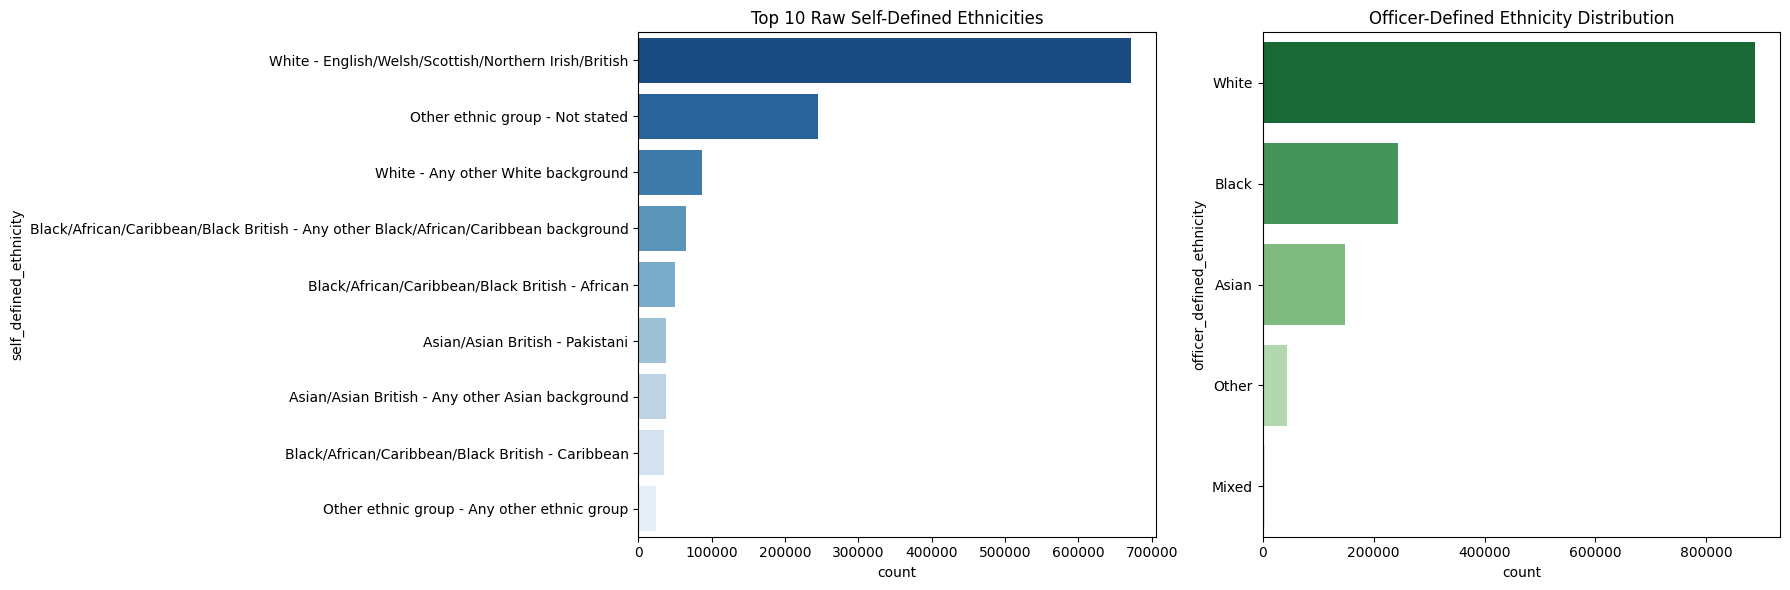

In [4]:
self_eth_raw = df.groupBy("self_defined_ethnicity").count().orderBy("count", ascending=False).limit(10).toPandas()
off_eth_raw = df.groupBy("officer_defined_ethnicity").count().orderBy("count", ascending=False).toPandas()

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=self_eth_raw, 
    x="count", 
    y="self_defined_ethnicity", 
    ax=ax[0], 
    palette="Blues_r", 
    hue="self_defined_ethnicity", 
    legend=False
)
ax[0].set_title("Top 10 Raw Self-Defined Ethnicities")

sns.barplot(
    data=off_eth_raw, 
    x="count", 
    y="officer_defined_ethnicity", 
    ax=ax[1], 
    palette="Greens_r", 
    hue="officer_defined_ethnicity", 
    legend=False
)
ax[1].set_title("Officer-Defined Ethnicity Distribution")

plt.tight_layout()
plt.show()

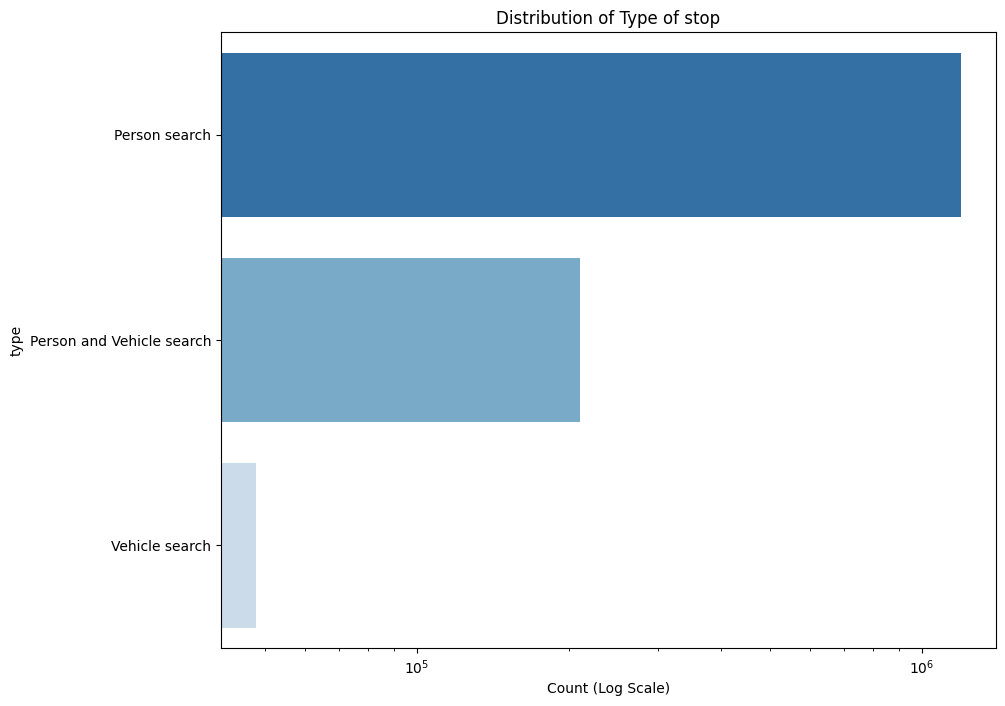

Sample of raw outcome strings:
['Person search', 'Person and Vehicle search', 'Vehicle search']


In [38]:
raw_outcomes = df.groupBy("type").count().orderBy("count", ascending=False).toPandas()

plt.figure(figsize=(10, 8))
sns.barplot(data=raw_outcomes, 
            x="count",
            y="type",
            palette="Blues_r",
            hue="type",
            legend=False)
plt.title("Distribution of Type of stop")
plt.xscale("log") # Using log scale because 'Nothing found' usually dwarfs others
plt.xlabel("Count (Log Scale)")
plt.show()

print("Sample of raw outcome strings:")
print(raw_outcomes['type'].head(15).tolist())

In [37]:
raw_outcomes = df.groupBy("involved_person").count().orderBy("count", ascending=False).toPandas()

raw_outcomes.head()

,involved_person,count
0,True,1403329
1,False,47968


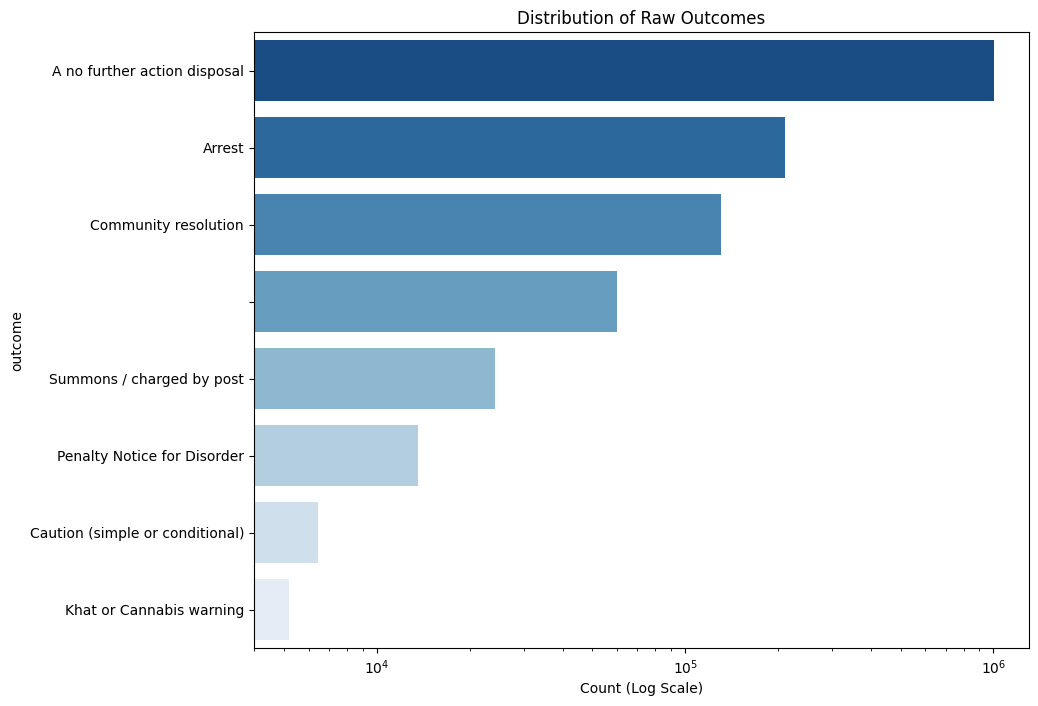

Sample of raw outcome strings:
['A no further action disposal', 'Arrest', 'Community resolution', '', 'Summons / charged by post', 'Penalty Notice for Disorder', 'Caution (simple or conditional)', 'Khat or Cannabis warning']


In [5]:
raw_outcomes = df.groupBy("outcome").count().orderBy("count", ascending=False).toPandas()

plt.figure(figsize=(10, 8))
sns.barplot(data=raw_outcomes, 
            x="count",
            y="outcome",
            palette="Blues_r",
            hue="outcome",
            legend=False)
plt.title("Distribution of Raw Outcomes")
plt.xscale("log") # Using log scale because 'Nothing found' usually dwarfs others
plt.xlabel("Count (Log Scale)")
plt.show()

print("Sample of raw outcome strings:")
print(raw_outcomes['outcome'].head(15).tolist())

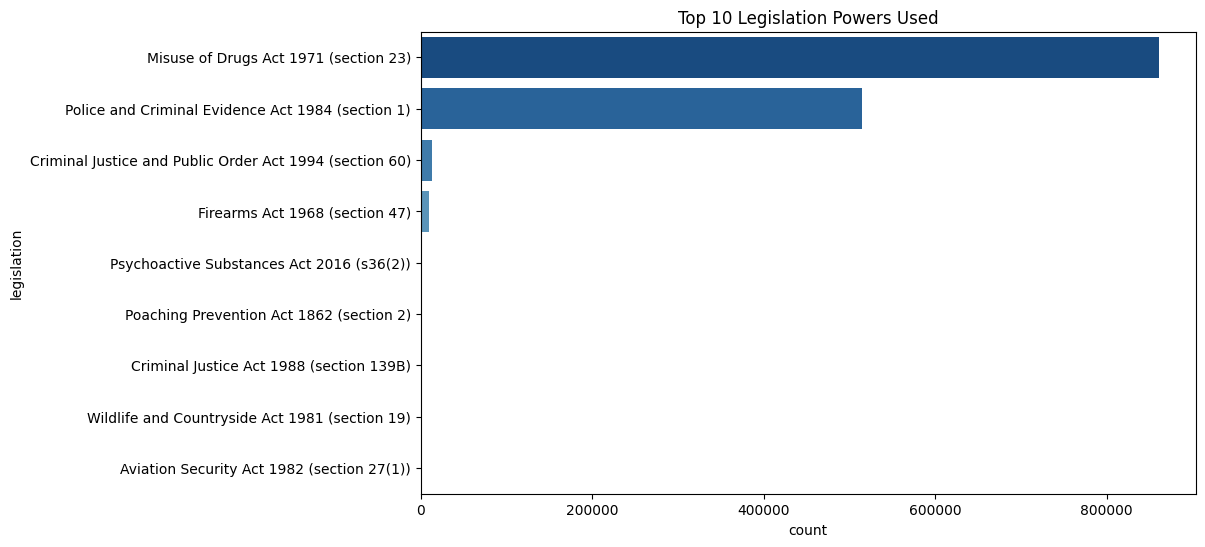

In [6]:
legislation_dist = df.groupBy("legislation").count().orderBy("count", ascending=False).limit(10).toPandas()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=legislation_dist, 
    x="count", 
    y="legislation", 
    palette="Blues_r", 
    hue="legislation", 
    legend=False
)
plt.title("Top 10 Legislation Powers Used")
plt.show()

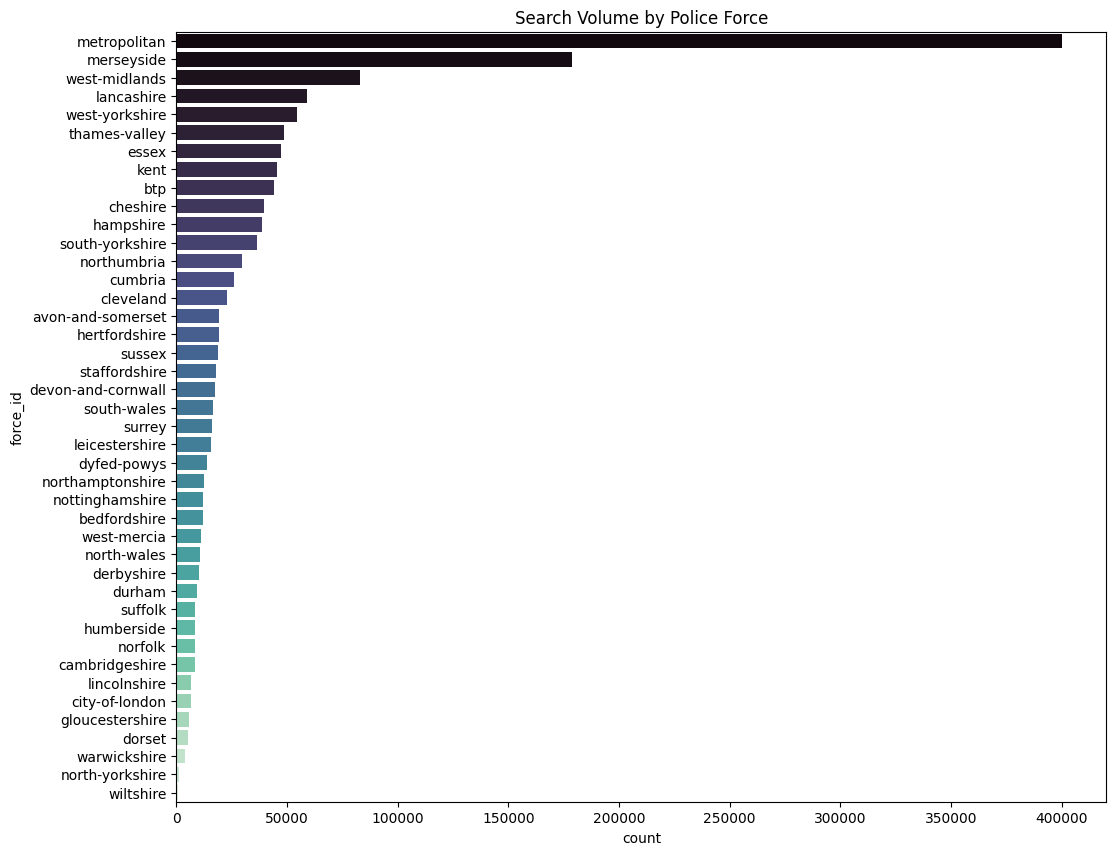

In [7]:
# Number of records per Police Force
force_dist = df.groupBy("force_id").count().orderBy("count", ascending=False).toPandas()

plt.figure(figsize=(12, 10))
sns.barplot(data=force_dist,
            x="count",
            y="force_id",
            palette="mako",
            hue="force_id", 
            legend=False)
plt.title("Search Volume by Police Force")
plt.show()

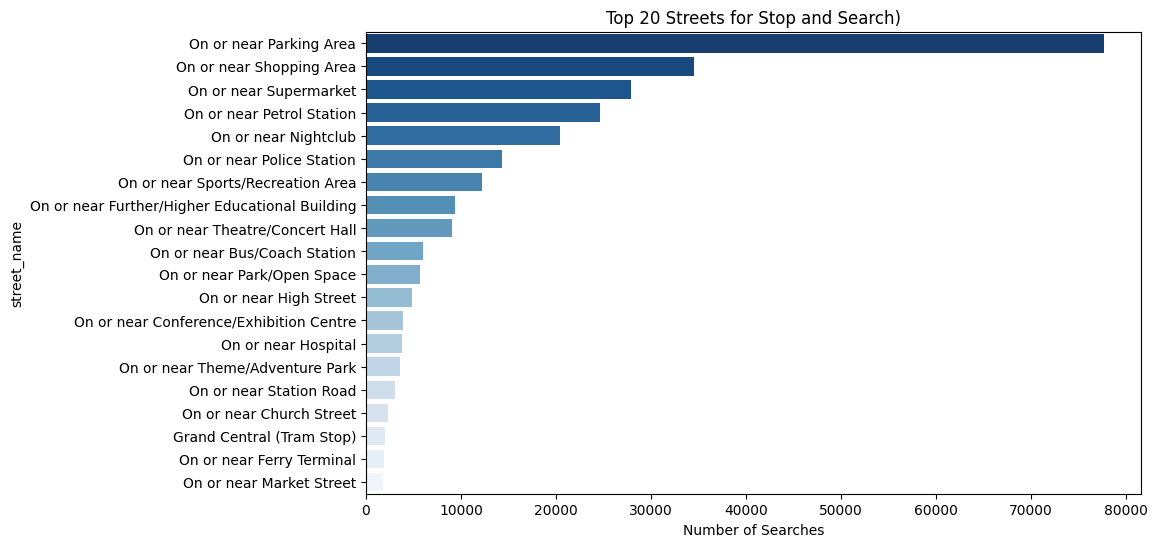

In [8]:
# Most frequent streets for stops
top_streets = df.filter(F.col("`location.street.name`").isNotNull()) \
    .groupBy("`location.street.name`") \
    .count() \
    .orderBy("count", ascending=False) \
    .select(F.col("`location.street.name`").alias("street_name"), 
            F.col("count")
    ).limit(20).toPandas()
plt.figure(figsize=(10, 6))
sns.barplot(data=top_streets,
            x="count",
            y="street_name",
            palette="Blues_r",
            hue="street_name",
            legend=False
           )
plt.title("Top 20 Streets for Stop and Search)")
plt.xlabel("Number of Searches")
plt.show()

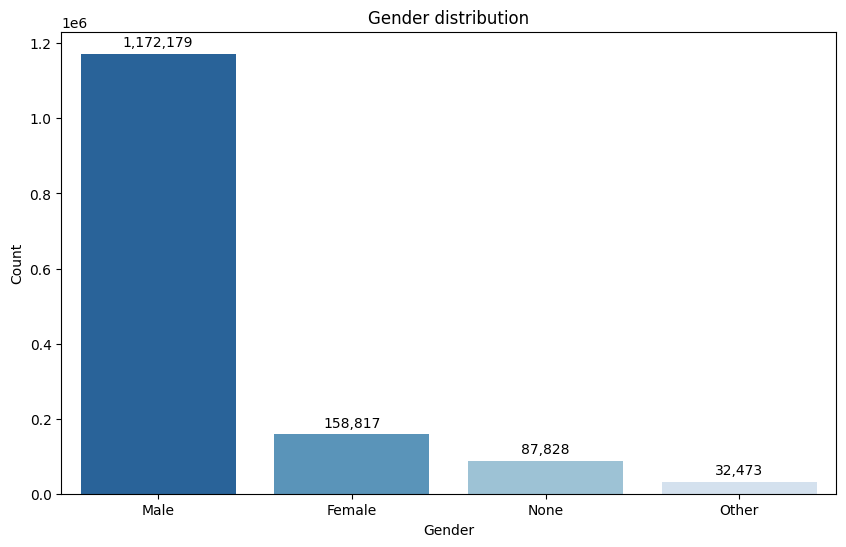

In [9]:
count_data = df.groupBy("gender").count().sort(F.col("count"),ascending=False).toPandas()
count_data['gender'] = count_data['gender'].fillna('None')


plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=count_data, 
    x="gender", 
    y="count", 
    hue="gender",   
    palette="Blues_r", 
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3)

plt.title("Gender distribution")
plt.ylabel("Count")
plt.xlabel("Gender")
plt.show()

Due to the small quantity of non Male or Female gender for the first visualization of the relation between ethnicity and gender

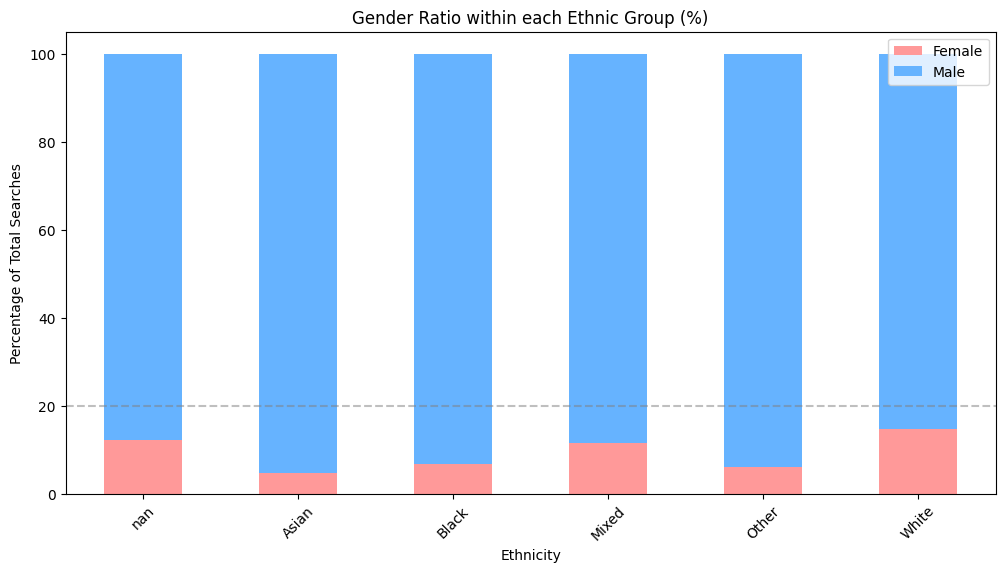

In [10]:
gender_eth_stats = df.filter(F.col("gender").isin("Male", "Female")) \
    .groupBy("officer_defined_ethnicity", "gender") \
    .count() \
    .orderBy("officer_defined_ethnicity") \
    .toPandas()

pivot_df = gender_eth_stats.pivot(index='officer_defined_ethnicity', columns='gender', values='count')
pivot_df_perc = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

pivot_df_perc.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#ff9999','#66b3ff'])
plt.title("Gender Ratio within each Ethnic Group (%)")
plt.ylabel("Percentage of Total Searches")
plt.xlabel("Ethnicity")
plt.axhline(20, color='gray', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.show()

# Data preprocessing

In [11]:
df = df\
    .withColumn("year", F.year(F.col("datetime")))\
    .withColumn("dayofyear", F.dayofyear(F.col("datetime")))\
    .withColumn("dayofweek", F.dayofweek(F.col("datetime")))\
    .withColumn("hour", F.hour(F.col("datetime")))\
    .withColumn("month", F.month(F.col("datetime")))
df.select('dayofyear', 'dayofweek','hour', 'month','year', 'datetime').first()

Row(dayofyear=289, dayofweek=5, hour=23, month=10, year=2025, datetime='2025-10-16T21:59:57+00:00')

To keep our model efficient and focused on the core problem of systemic bias, we are dropping several columns that are either redundant, too specific, or filled with missing information. 

First, we are removing **`datetime`** because we have already extracted its useful parts (like the hour and the month), so the raw timestamp is no longer needed. We are also discarding **`operation`** and **`operation_name`** because they are usually empty or refer to very specific, one-time events that don't help us find general patterns in police behavior. 

Regarding the outcomes, we are dropping **`outcome_linked_to_object_of_search`** and **`outcome_object`** to simplify our target variable; since we are focusing strictly on whether an arrest happened or not, these extra details just add noise to the model. Finally, we are excluding **`self_defined_ethnicity`** in favor of the officer-defined version. We do this because the self-defined list has too many tiny sub-categories that make the Decision Tree messy, and more importantly, because studying the **officer's perception** is the key to identifying the potential prejudices that lead to a search in the first place. 

By cleaning the dataset this way, we ensure that Spark runs much faster and the Decision Tree stays focused on the variables that actually matter for our bias audit.

In [12]:
cols_to_drop = [
    "operation",
    "operation_name",
    "outcome_linked_to_object_of_search",
    "outcome_object",
    "self_defined_ethnicity",
]
df_filtered = df.drop(*cols_to_drop)

df_filtered = df_filtered.select(    
    F.col("age_range").alias("age"),
    F.col("outcome").alias("outcome"),
    F.col("involved_person").alias("is_person"),
    F.col("gender").alias("gender"),
    F.col("legislation").alias("law"),
    F.col("year"),
    F.to_timestamp("datetime").alias("timestamp"),
    F.col("dayofyear"),
    F.col("dayofweek"),
    F.col("hour"),
    F.col("month"),
    F.col("removal_of_more_than_outer_clothing").alias("strip_search"),
    F.col("officer_defined_ethnicity").alias("ethnicity"),
    F.col("type").alias("search_type"),
    F.col("object_of_search").alias("reason"),
    F.col("force_id").alias("police_force"),
    F.col("`location.latitude`").alias("latitude"),
    F.col("`location.longitude`").alias("longitude"),
    F.col("`location.street.id`").alias("street_id"),
    F.col("`location.street.name`").alias("street_name")
)

In [13]:
# List of outcomes that represent a "successful" search (some form of legal trouble)
positive_outcomes = [
    'Arrest', 
    'Community resolution', 
    'Summons / charged by post', 
    'Penalty Notice for Disorder', 
    'Caution (simple or conditional)', 
    'Khat or Cannabis warning'
]

# Create the new binary target variable
df_filtered = df_filtered.withColumn("legal_action_taken", 
    F.when(F.col("outcome").isin(positive_outcomes), 1).otherwise(0)
)
# Check the distribution
df_filtered.groupBy("legal_action_taken").count().show()

+------------------+-------+
|legal_action_taken|  count|
+------------------+-------+
|                 1| 390760|
|                 0|1060537|
+------------------+-------+



In [14]:
# Calculate how many rows have valid coordinates
geo_completeness = df_filtered.select(
    F.count(F.when(F.col("latitude").isNotNull(), 1)).alias("With_coords"),
    F.count(F.when(F.col("latitude").isNull(), 1)).alias("Without_coords"),
    F.count(F.when(F.col("police_force").isNull(), 1)).alias("Without Police force"),
).toPandas()

print("Geographical Data Completeness:")
geo_completeness

Geographical Data Completeness:


,With_coords,Without_coords,Without Police force
0,1291544,159753,0


We decided to use the **`police_force`** as our primary geographical feature instead of coordinates or street names because it is much more reliable and practical for a Big Data study. Using exact latitude and longitude or thousands of different street names is problematic because that data is often incomplete or missing, and there are so many unique streets that the model would just get overwhelmed and start _"memorizing"_ specific corners instead of finding real patterns. 

The main idea is: instead of trying to track every single floor tile a person steps on, it’s much more useful to know which building they are in and what the rules are there. By focusing on the police force, we can see the institutional "vibe" and specific policies of a whole department like comparing the Metropolitan Police to Greater Manchester making our bias audit much clearer, more scalable, and way more professional.

In [15]:
cols_to_drop = [
    "latitude",
    "longitude",
    "street_id",
    "street_name",
    'outcome'
]
df_final = df_filtered.drop(*cols_to_drop)
df_final.printSchema()

root
 |-- age: string (nullable = true)
 |-- is_person: boolean (nullable = true)
 |-- gender: string (nullable = true)
 |-- law: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- dayofyear: integer (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- strip_search: boolean (nullable = true)
 |-- ethnicity: string (nullable = true)
 |-- search_type: string (nullable = true)
 |-- reason: string (nullable = true)
 |-- police_force: string (nullable = true)
 |-- legal_action_taken: integer (nullable = false)



In [16]:
# Convert Booleans to Integers (0 or 1) for the model
df_ml = df_final.withColumn("is_person", F.col("is_person").cast("int")) \
                .withColumn("strip_search", F.col("strip_search").cast("int"))

# Check for nulls one last time to avoid breaking the pipeline
df_ml = df_ml.fillna("Unknown", subset=["age", "gender", "law", "ethnicity", "search_type", "reason", "police_force"])
df_ml = df_ml.fillna(0, subset=["hour", "month", "dayofweek", "dayofyear"])
df_ml.printSchema()

root
 |-- age: string (nullable = false)
 |-- is_person: integer (nullable = true)
 |-- gender: string (nullable = false)
 |-- law: string (nullable = false)
 |-- year: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- dayofyear: integer (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- strip_search: integer (nullable = true)
 |-- ethnicity: string (nullable = false)
 |-- search_type: string (nullable = false)
 |-- reason: string (nullable = false)
 |-- police_force: string (nullable = false)
 |-- legal_action_taken: integer (nullable = false)



In [17]:
from pyspark.sql import functions as F


# Define the split point (e.g., everything before 2024 for training)
train_df = df_ml.filter(F.col('year') < 2024)
test_df = df_ml.filter(F.col('year')>= 2024)

print(f"Training set: {train_df.count():,} records (Years < 2024)")
print(f"Testing set: {test_df.count():,} records (Year 2024+)")

Training set: 575,734 records (Years < 2024)
Testing set: 875,563 records (Year 2024+)


### Cross validation time series 

In [18]:
from multiprocessing.pool import ThreadPool
from pyspark import keyword_only
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.param import Params, Param, TypeConverters

class tsCrossValidator(CrossValidator):
    """
    Custom validator for time-series cross-validation.

    This class extends the functionality of PySpark's CrossValidator to support
    walk-forward time-series cross-validation. It splits the dataset into
    consecutive periods with each fold using data from the past as training
    and the most recent period as validation.

    In particular, it overrides the _kFold method (which is used in the fit method)
    """
    datetimeCol = Param(
        Params._dummy(), 
        "datetimeCol", 
        "Column name for splitting the data",
        typeConverter=TypeConverters.toString)
    
    timeSplit = Param(
        Params._dummy(), 
        "timeSplit", 
        "Length of time to leave in validation set. Should be some sort of timedelta or relativedelta")
    
    gap = Param(
        Params._dummy(), 
        "gap", 
        "Length of time to leave bas gap between train and validation")
    
    disableExpandingWindow = Param(
        Params._dummy(),
        "disableExpandingWindow",
        "Boolean for disabling expanding window folds and taking rolling windows instead.",
        typeConverter=TypeConverters.toBoolean)

    @keyword_only
    def __init__(self, estimator=None, estimatorParamMaps=None, evaluator=None,
                 numFolds=3, datetimeCol = 'date', timeSplit=None, 
                 gap=None, disableExpandingWindow=False, parallelism=1, collectSubModels=False):

        super(tsCrossValidator, self).__init__(
            estimator=estimator, 
            estimatorParamMaps=estimatorParamMaps, 
            evaluator=evaluator, 
            numFolds=numFolds,
            parallelism=parallelism, 
            collectSubModels=collectSubModels
        )
       
        self._setDefault(gap=None, datetimeCol='date', timeSplit=None, disableExpandingWindow=False)

        # Explicitly set the provided values
        self._set(gap=gap, datetimeCol=datetimeCol, timeSplit=timeSplit, disableExpandingWindow=disableExpandingWindow)

        kwargs = self._input_kwargs
        self._set(**kwargs)
    
    def getDatetimeCol(self):
        return self.getOrDefault(self.datetimeCol)
    
    def setDatetimeCol(self, datetimeCol):
        return self._set(datetimeCol=datetimeCol)
    
    def getTimeSplit(self):
        return self.getOrDefault(self.timeSplit)
    
    def setTimeSplit(self, timeSplit):
        return self._set(timeSplit=timeSplit)
    
    def getDisableExpandingWindow(self):
        return self.getOrDefault(self.disableExpandingWindow)
    
    def setDisableExpandingWindow(self, disableExpandingWindow):
        return self._set(disableExpandingWindow=disableExpandingWindow)
    
    def getGap(self):
        return self.getOrDefault(self.gap)

    def setGap(self, gap):
        return self._set(gap=gap)

    def _kFold(self, dataset):
        nFolds = self.getOrDefault(self.numFolds)
        datetimeCol = self.getOrDefault(self.datetimeCol)
        timeSplit = self.getOrDefault(self.timeSplit)
        gap = self.getOrDefault(self.gap)
        disableExpandingWindow = self.getOrDefault(self.disableExpandingWindow)

        datasets = []
        endDate = dataset.agg({datetimeCol : 'max'}).collect()[0][0]
        trainLB = dataset.agg({datetimeCol: 'min'}).collect()[0][0]
        for i in reversed(range(nFolds)):
            validateUB = endDate - i * timeSplit
            validateLB = endDate - (i + 1) * timeSplit
            trainUB = validateLB - gap if gap is not None else validateLB

            val_condition = (dataset[datetimeCol] > validateLB) & (dataset[datetimeCol] <= validateUB)
            train_condition = (dataset[datetimeCol] <= trainUB) & (dataset[datetimeCol] >= trainLB)

            validation = dataset.filter(val_condition)
            train = dataset.filter(train_condition)

            datasets.append((train, validation))

            if disableExpandingWindow:
                trainLB += timeSplit
        
        return datasets

In [23]:
# Convert Booleans and ensure all numerical types are correct
df_final = df_final.withColumn("is_person", F.col("is_person").cast("int")) \
              .withColumn("strip_search", F.col("strip_search").cast("int"))

# Final Null check to prevent VectorAssembler crashes
categorical_cols = ["age", "gender", "law", "ethnicity", "search_type", "reason", "police_force"]
df_final = df_final.fillna("Unknown", subset=categorical_cols)
df_final = df_final.fillna(0, subset=["hour", "month", "dayofweek", "dayofyear","strip_search" ])

df_final.printSchema()

root
 |-- age: string (nullable = false)
 |-- is_person: integer (nullable = true)
 |-- gender: string (nullable = false)
 |-- law: string (nullable = false)
 |-- year: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- dayofyear: integer (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- strip_search: integer (nullable = true)
 |-- ethnicity: string (nullable = false)
 |-- search_type: string (nullable = false)
 |-- reason: string (nullable = false)
 |-- police_force: string (nullable = false)
 |-- legal_action_taken: integer (nullable = false)



In [26]:
from dateutil.relativedelta import relativedelta
import time

# Verify final dataset before pipeline
print(f"Final dataset count before pipeline: {df_final.count()}")
assert df_final.count() > 0, "Dataset is empty before pipeline!"

# 1. String Indexers
indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep") 
    for col in categorical_cols
]

# 2. Vector Assembler
numeric_cols = ["is_person", "strip_search", "hour", "month", "dayofweek", "dayofyear"]
feature_cols = [f"{col}_idx" for col in categorical_cols] + numeric_cols
assembler = VectorAssembler(
    inputCols=feature_cols, 
    outputCol="features",
    handleInvalid="keep"
)

# 3. Decision Tree Estimator
dt = DecisionTreeClassifier(
    labelCol="legal_action_taken", 
    featuresCol="features", 
    maxDepth=5, 
    maxBins=64, 
    seed=42
)

# 4. Construct the Pipeline
pipeline = Pipeline(stages=indexers + [assembler, dt])

# 5. Evaluator
evaluator = BinaryClassificationEvaluator(
    rawPredictionCol='rawPrediction',  # Changed from 'prediction'
    labelCol='legal_action_taken'
)

# 6. Parameter Grid
paramGrid = (ParamGridBuilder() 
    .addGrid(dt.maxDepth, [5, 8])
    .addGrid(dt.maxBins, [64, 128])
    .build())

# 7. Time Series Cross Validator
ts_cv = tsCrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=6,
    datetimeCol='timestamp',
    timeSplit=relativedelta(months=2),
    gap=relativedelta(days=0),
    parallelism=2
)

# 8. Fit with error handling
try:
    print("Starting Pipeline Training with Temporal Cross-Validation...")
    start_time = time.time()
    
    # This will call your custom _kFold logic internally
    cv_model = ts_cv.fit(df_final)
    
    total_time = time.time() - start_time
    print(f"Pipeline fitting complete. Total time: {total_time:.2f} seconds.")
    
    # Extract the Best Model and Audit the Bias
    best_model = cv_model.bestModel
    best_tree = best_model.stages[-1]
    
    print(f"Best Model MaxDepth: {best_tree.getOrDefault('maxDepth')}")
except Exception as e:
    print(f"Error during fitting: {e}")
    # Additional debugging
    print("\nDataset sample:")
    df_final.select("legal_action_taken", "timestamp", *categorical_cols[:3]).show(5)
    raise

Final dataset count before pipeline: 1451297
Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 230.21 seconds.
Best Model MaxDepth: 8


In [27]:
best_tree

DecisionTreeClassificationModel: uid=DecisionTreeClassifier_46c5ac693262, depth=8, numNodes=161, numClasses=2, numFeatures=13

In [29]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql import functions as F

# 1. Obtener el mejor modelo del cross-validator
best_model = cv_model.bestModel

# 2. Preparar el dataset de test (aplicar las mismas transformaciones)
# Asegúrate de que test_df tenga las mismas columnas y limpieza que df_final
test_df = test_df.withColumn("is_person", F.col("is_person").cast("int")) \
                     .withColumn("strip_search", F.col("strip_search").cast("int"))

test_df = test_df.fillna("Unknown", subset=categorical_cols)
test_df = test_df.fillna(0, subset=["hour", "month", "dayofweek", "dayofyear"])

# Limpiar NaN
all_numeric = ["is_person", "strip_search", "hour", "month", "dayofweek", "dayofyear"]
for col_name in all_numeric:
    test_df = test_df.withColumn(
        col_name,
        F.when(F.isnan(col_name), 0).otherwise(F.col(col_name))
    )

test_df = test_df.filter(F.col("legal_action_taken").isNotNull())
test_df = test_df.withColumn("legal_action_taken", F.col("legal_action_taken").cast("int"))

print(f"Test data size: {test_df.count()}")

# 3. Hacer predicciones
predictions = best_model.transform(test_df)

# 4. Mostrar algunas predicciones
print("\nSample predictions:")
predictions.select("legal_action_taken", "prediction", "probability").show(10, truncate=False)

# 5. Evaluar métricas

# Métricas de clasificación binaria
binary_evaluator_auc = BinaryClassificationEvaluator(
    labelCol="legal_action_taken",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

binary_evaluator_pr = BinaryClassificationEvaluator(
    labelCol="legal_action_taken",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderPR"
)

auc = binary_evaluator_auc.evaluate(predictions)
auc_pr = binary_evaluator_pr.evaluate(predictions)

print(f"\nArea Under ROC Curve (AUC-ROC): {auc:.4f}")
print(f"Area Under PR Curve (AUC-PR): {auc_pr:.4f}")

# Métricas multiclase (Accuracy, Precision, Recall, F1)
multiclass_evaluator = MulticlassClassificationEvaluator(
    labelCol="legal_action_taken",
    predictionCol="prediction"
)

accuracy = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "accuracy"})
precision = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "weightedPrecision"})
recall = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "weightedRecall"})
f1 = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "f1"})

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# 6. Matriz de confusión
print("\nConfusion Matrix:")
predictions.groupBy("legal_action_taken", "prediction").count().orderBy("legal_action_taken", "prediction").show()

# 7. Métricas por clase
print("\nMetrics by class:")
for label in [0, 1]:
    tp = predictions.filter((F.col("legal_action_taken") == label) & (F.col("prediction") == label)).count()
    fp = predictions.filter((F.col("legal_action_taken") != label) & (F.col("prediction") == label)).count()
    fn = predictions.filter((F.col("legal_action_taken") == label) & (F.col("prediction") != label)).count()
    tn = predictions.filter((F.col("legal_action_taken") != label) & (F.col("prediction") != label)).count()
    
    precision_class = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_class = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_class = 2 * (precision_class * recall_class) / (precision_class + recall_class) if (precision_class + recall_class) > 0 else 0
    
    print(f"\nClass {label}:")
    print(f"  Precision: {precision_class:.4f}")
    print(f"  Recall: {recall_class:.4f}")
    print(f"  F1-Score: {f1_class:.4f}")
    print(f"  Support: {tp + fn}")

# 8. Distribución de clases
print("\nClass distribution in predictions:")
predictions.groupBy("prediction").count().show()

print("\nClass distribution in actual labels:")
predictions.groupBy("legal_action_taken").count().show()

# 9. Guardar predicciones si es necesario
# predictions.select("legal_action_taken", "prediction", "probability").write.parquet("predictions.parquet")

Test data size: 875563

Sample predictions:
+------------------+----------+----------------------------------------+
|legal_action_taken|prediction|probability                             |
+------------------+----------+----------------------------------------+
|0                 |0.0       |[0.8179768662855054,0.18202313371449463]|
|0                 |0.0       |[0.846079380445305,0.15392061955469508] |
|0                 |0.0       |[0.8732635459872276,0.1267364540127724] |
|1                 |0.0       |[0.8179768662855054,0.18202313371449463]|
|0                 |0.0       |[0.8179768662855054,0.18202313371449463]|
|1                 |0.0       |[0.8179768662855054,0.18202313371449463]|
|1                 |0.0       |[0.693987941306994,0.3060120586930059]  |
|0                 |0.0       |[0.693987941306994,0.3060120586930059]  |
|0                 |0.0       |[0.693987941306994,0.3060120586930059]  |
|0                 |0.0       |[0.693987941306994,0.3060120586930059]  |
+------


Area Under ROC Curve (AUC-ROC): 0.5670
Area Under PR Curve (AUC-PR): 0.3098



Accuracy: 0.7216
Weighted Precision: 0.6225
Weighted Recall: 0.7216
F1 Score: 0.6147

Confusion Matrix:


+------------------+----------+------+
|legal_action_taken|prediction| count|
+------------------+----------+------+
|                 0|       0.0|628316|
|                 0|       1.0|  6419|
|                 1|       0.0|237369|
|                 1|       1.0|  3459|
+------------------+----------+------+


Metrics by class:



Class 0:
  Precision: 0.7258
  Recall: 0.9899
  F1-Score: 0.8375
  Support: 634735



Class 1:
  Precision: 0.3502
  Recall: 0.0144
  F1-Score: 0.0276
  Support: 240828

Class distribution in predictions:


+----------+------+
|prediction| count|
+----------+------+
|       0.0|865685|
|       1.0|  9878|
+----------+------+


Class distribution in actual labels:
+------------------+------+
|legal_action_taken| count|
+------------------+------+
|                 1|240828|
|                 0|634735|
+------------------+------+

